# Analyze Training Results
Load trained model, evaluate on test set, and diagnose accuracy issues.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, '../src')

from models.cnn_model import TemporalCNN
from dataset import get_dataloaders
import config

print(f"Device: {config.DEVICE}")
print(f"Model path: checkpoints/best_model.pth")
print(f"Config: {config.INPUT_FEATURES} features, {config.NUM_CLASSES} classes, {config.MAX_FRAMES} frames")

Device: cpu
Model path: checkpoints/best_model.pth
Config: 225 features, 100 classes, 48 frames


In [2]:
# Load trained model
device = torch.device(config.DEVICE)
model = TemporalCNN(
    input_features=config.INPUT_FEATURES,
    num_classes=config.NUM_CLASSES,
    dropout=config.DROPOUT
).to(device)

model.load_state_dict(torch.load('../checkpoints/best_model.pth'))
model.eval()

print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded. Parameters: 737,636


In [4]:
# Load test data
# Note: Fix path since notebook runs from /notebooks directory
import os
os.chdir('..')  # Change to project root

train_loader, val_loader, test_loader = get_dataloaders(config.DATA_DIR, config.BATCH_SIZE)

# Also load class names and true labels
test_data_path = Path(config.DATA_DIR) / 'test'
y_test = np.load(test_data_path / 'y.npy')
class_names = np.load(test_data_path / 'class_names.npy')

print(f"Test set: {len(y_test)} samples, {len(class_names)} classes")

Loaded 1001 samples
Feature shape: (1001, 48, 225)
Loaded 242 samples
Feature shape: (242, 48, 225)
Loaded 200 samples
Feature shape: (200, 48, 225)
Test set: 200 samples, 100 classes


In [5]:
# Evaluate on test set with per-class accuracy
all_predictions = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = outputs.max(1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Overall accuracy
overall_acc = (all_predictions == all_labels).mean() * 100
print(f"\nOverall Test Accuracy: {overall_acc:.2f}%")

/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/notebooks/../src/dataset.py:35: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  features = torch.FloatTensor(self.features[idx])  # [30, 225]



Overall Test Accuracy: 38.50%


In [7]:
# Per-class accuracy
from sklearn.metrics import classification_report, confusion_matrix

# Get unique classes that actually appear in test set
unique_test_classes = np.unique(all_labels)
test_class_names = class_names[unique_test_classes]

report = classification_report(all_labels, all_predictions, 
                                target_names=test_class_names, 
                                labels=unique_test_classes,
                                output_dict=False, 
                                zero_division=0)
print(report)

              precision    recall  f1-score   support

    accident       0.50      0.33      0.40         3
      africa       0.33      0.50      0.40         2
         all       0.00      0.00      0.00         2
       apple       0.00      0.00      0.00         1
  basketball       1.00      0.50      0.67         2
         bed       1.00      1.00      1.00         2
      before       0.20      0.33      0.25         3
        bird       1.00      0.50      0.67         2
    birthday       0.00      0.00      0.00         2
       black       1.00      0.33      0.50         3
        blue       1.00      0.50      0.67         2
     bowling       0.00      0.00      0.00         2
       brown       0.67      1.00      0.80         2
         but       0.00      0.00      0.00         2
         can       0.50      1.00      0.67         1
       candy       0.40      0.67      0.50         3
       chair       0.33      0.50      0.40         2
      change       0.00    

In [8]:
# Per-class accuracy analysis
per_class_acc = {}
for class_idx in range(len(class_names)):
    mask = all_labels == class_idx
    if mask.sum() > 0:
        acc = (all_predictions[mask] == class_idx).mean() * 100
        per_class_acc[class_names[class_idx]] = acc

# Sort by accuracy
sorted_acc = dict(sorted(per_class_acc.items(), key=lambda x: x[1]))

print("\nWorst 10 classes (lowest accuracy):")
for i, (class_name, acc) in enumerate(list(sorted_acc.items())[:10]):
    print(f"  {i+1}. {class_name}: {acc:.1f}%")

print("\nBest 10 classes (highest accuracy):")
for i, (class_name, acc) in enumerate(list(sorted_acc.items())[-10:]):
    print(f"  {i+1}. {class_name}: {acc:.1f}%")


Worst 10 classes (lowest accuracy):
  1. all: 0.0%
  2. apple: 0.0%
  3. birthday: 0.0%
  4. bowling: 0.0%
  5. but: 0.0%
  6. change: 0.0%
  7. cook: 0.0%
  8. cool: 0.0%
  9. cousin: 0.0%
  10. doctor: 0.0%

Best 10 classes (highest accuracy):
  1. language: 100.0%
  2. orange: 100.0%
  3. pink: 100.0%
  4. play: 100.0%
  5. shirt: 100.0%
  6. short: 100.0%
  7. son: 100.0%
  8. table: 100.0%
  9. who: 100.0%
  10. wrong: 100.0%


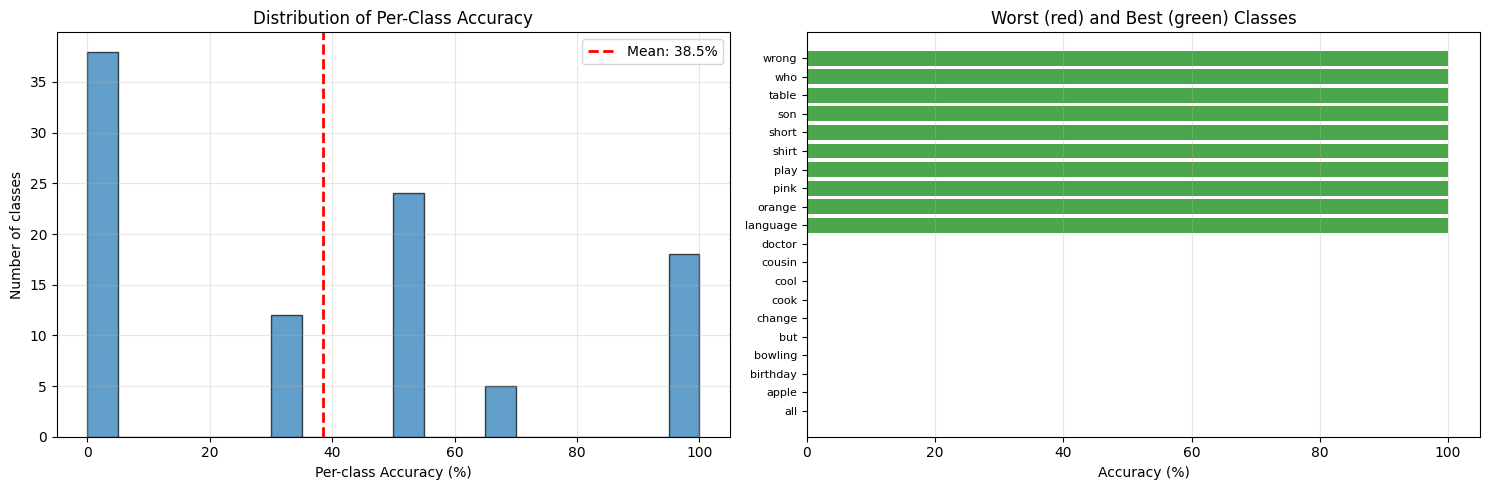

In [9]:
# Visualize per-class accuracy distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of per-class accuracy
ax = axes[0]
accuracies = list(per_class_acc.values())
ax.hist(accuracies, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(np.mean(accuracies), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(accuracies):.1f}%')
ax.set_xlabel('Per-class Accuracy (%)')
ax.set_ylabel('Number of classes')
ax.set_title('Distribution of Per-Class Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Worst vs Best classes
ax = axes[1]
worst_10 = dict(list(sorted_acc.items())[:10])
best_10 = dict(list(sorted_acc.items())[-10:])

all_names = list(worst_10.keys()) + list(best_10.keys())
all_accs = list(worst_10.values()) + list(best_10.values())
colors = ['red']*10 + ['green']*10

ax.barh(range(len(all_names)), all_accs, color=colors, alpha=0.7)
ax.set_yticks(range(len(all_names)))
ax.set_yticklabels(all_names, fontsize=8)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Worst (red) and Best (green) Classes')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

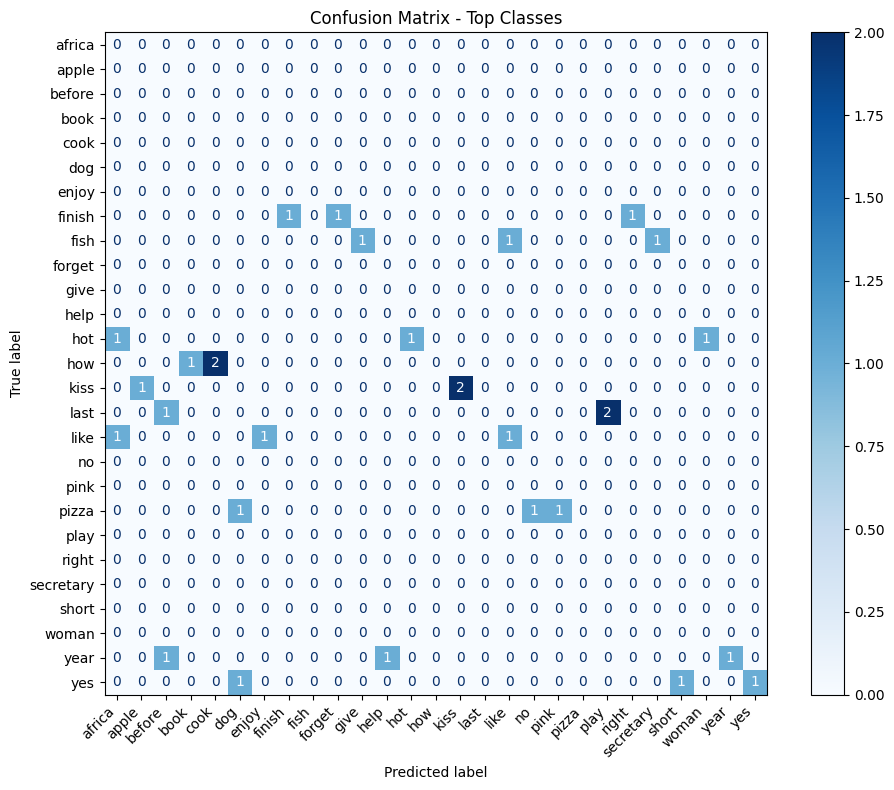

Confusion matrix shows 27 classes (classes that appear in top 10)


In [11]:
# Confusion matrix - sample subset for visualization
from sklearn.metrics import ConfusionMatrixDisplay

# Get unique classes present in test set and pick top 10 most frequent
unique_classes, counts = np.unique(all_labels, return_counts=True)
top_10_indices = unique_classes[np.argsort(counts)[-10:]]

# Filter predictions and labels to only include top 10 classes
mask = np.isin(all_labels, top_10_indices)
filtered_labels = all_labels[mask]
filtered_predictions = all_predictions[mask]

# Get unique classes that actually appear in both true and predicted labels
unique_in_filtered = np.unique(np.concatenate([filtered_labels, filtered_predictions]))

# Remap labels to 0-(n_classes-1) range
label_mapping = {old: new for new, old in enumerate(unique_in_filtered)}
remapped_labels = np.array([label_mapping[label] for label in filtered_labels])
remapped_predictions = np.array([label_mapping[pred] for pred in filtered_predictions])

cm = confusion_matrix(remapped_labels, remapped_predictions)

# Create display labels for only the classes that appear
display_labels = [class_names[i] for i in unique_in_filtered]

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Top Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Confusion matrix shows {len(display_labels)} classes (classes that appear in top 10)")

In [13]:
# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Overall Test Accuracy: {overall_acc:.2f}%")
print(f"\nPer-class accuracy statistics:")
print(f"  Mean: {np.mean(accuracies):.2f}%")
print(f"  Median: {np.median(accuracies):.2f}%")
print(f"  Std: {np.std(accuracies):.2f}%")
print(f"  Min: {np.min(accuracies):.2f}%")
print(f"  Max: {np.max(accuracies):.2f}%")
print(f"\nClasses with 0% accuracy: {sum(1 for acc in accuracies if acc == 0)}")
print(f"Classes with >50% accuracy: {sum(1 for acc in accuracies if acc > 50)}")
print(f"Classes with >80% accuracy: {sum(1 for acc in accuracies if acc > 80)}")


SUMMARY STATISTICS
Overall Test Accuracy: 38.50%

Per-class accuracy statistics:
  Mean: 38.49%
  Median: 33.33%
  Std: 36.87%
  Min: 0.00%
  Max: 100.00%

Classes with 0% accuracy: 38
Classes with >50% accuracy: 23
Classes with >80% accuracy: 18
